In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.api as tsa

In [28]:
PLOT_SIZE = (10, 6)
PLOT_SIZE_X = PLOT_SIZE[0]
PLOT_SIZE_Y = PLOT_SIZE[1]

In [29]:
def general_plot(data, file, xlabel=None, ylabel=None, title=None, save_file=False):
    fig, ax = plt.subplots(figsize=PLOT_SIZE)
    sns.set_style("whitegrid")
    ax.plot(data, color="black")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if save_file:
        fig.savefig(
            file,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )   
    plt.show()

def decomp_plot(data, file, save_file=False):
    decomp_result = tsa.seasonal_decompose(data)
    fig = decomp_result.plot()
    fig.set_size_inches(PLOT_SIZE_X, PLOT_SIZE_Y)
    axes = fig.get_axes()

    for ax in axes:
        for line in ax.get_lines():
            line.set_color("black")
    
    axes[3].get_lines()[1].set_color("black")

    axes[0].set_title(None)
    axes[0].set_ylabel("Szereg czasowy")
    axes[1].set_ylabel("Trend")
    axes[2].set_ylabel("Sezonowość")
    axes[3].set_ylabel("Reszty")
    if save_file:
        fig.savefig(
            file,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )
    plt.show()

In [30]:
monthly_data = pd.read_excel("../data/dane.xlsx", sheet_name="miesięczne", parse_dates=["data"], index_col="data")
quarterly_data = pd.read_excel("../data/dane.xlsx", sheet_name="kwartalne", parse_dates=["data"], index_col="data")
yearly_data = pd.read_excel("../data/dane.xlsx", sheet_name="roczne", parse_dates=["data"], index_col="data")

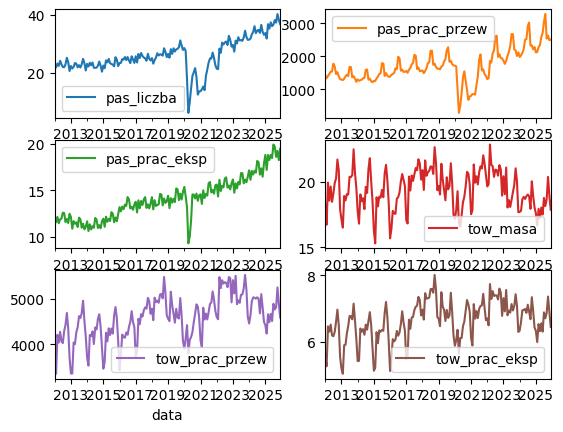

In [4]:
fig, ax = plt.subplots(3, 2)

monthly_data.plot(subplots=True, ax=ax)
plt.xlabel(None)
plt.show()

# Zmienna masa towarów w transporcie kolejowym

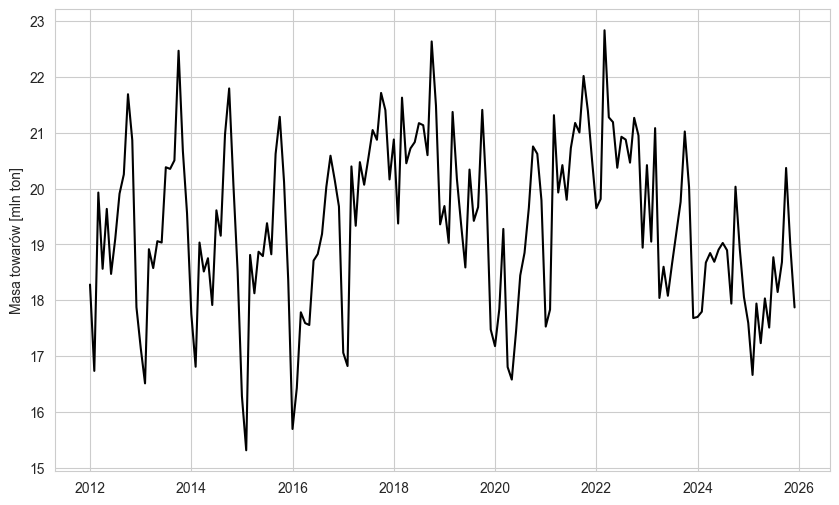

In [26]:
general_plot(
    monthly_data["tow_masa"],
    file="../figures/tow_masa.png",
    ylabel="Masa towarów [mln ton]",
    title=None,
    save_file=True
)

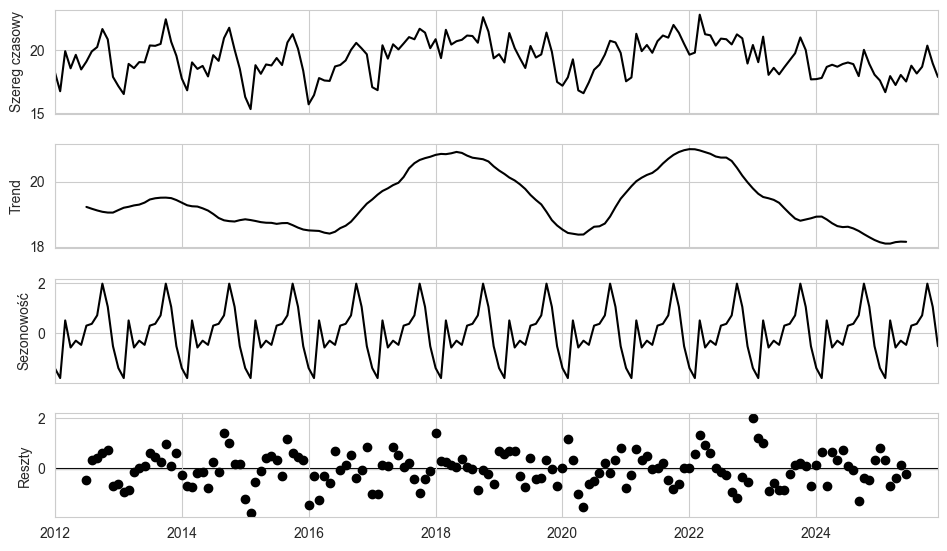

In [23]:
decomp_plot(
    monthly_data["tow_masa"],
    file="../figures/tow_masa_decomp.png",
    save_file=True
)


# Zmienna praca przewozowa w transporcie kolejowym towarowym

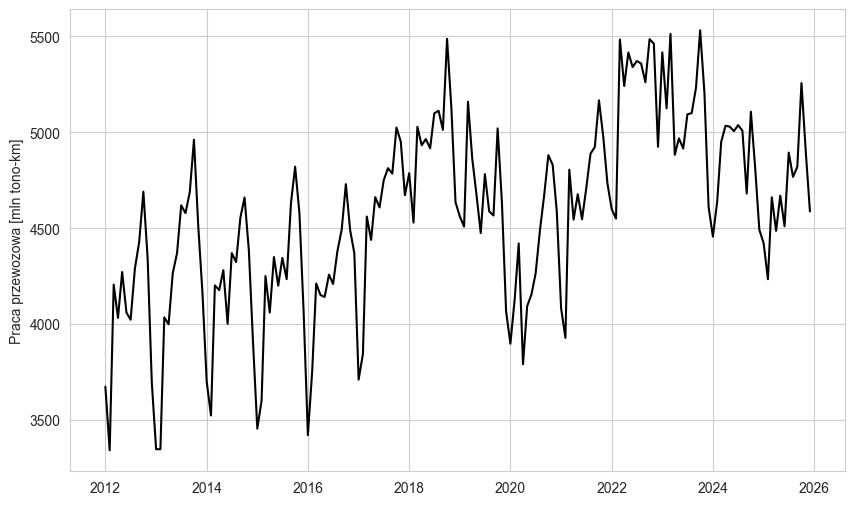

In [24]:
general_plot(
    monthly_data["tow_prac_przew"],
    file="../figures/tow_prac_przew.png",
    ylabel="Praca przewozowa [mln tono-km]",
    title=None,
    save_file=True
)

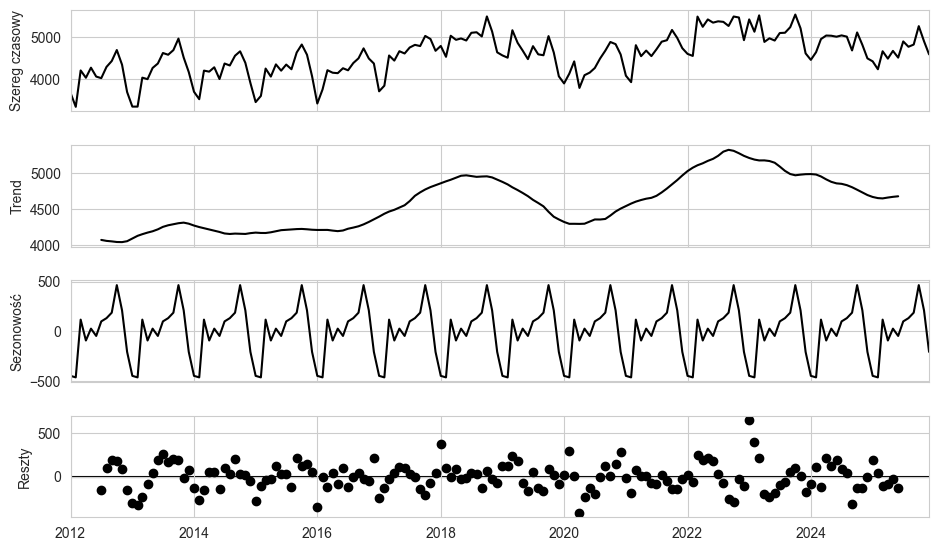

In [25]:
decomp_plot(
    monthly_data["tow_prac_przew"],
    file="../figures/tow_prac_przew_decomp.png",
    save_file=True
)

# Zmienna praca eksploatacyjna w transporcie kolejowym towarowym

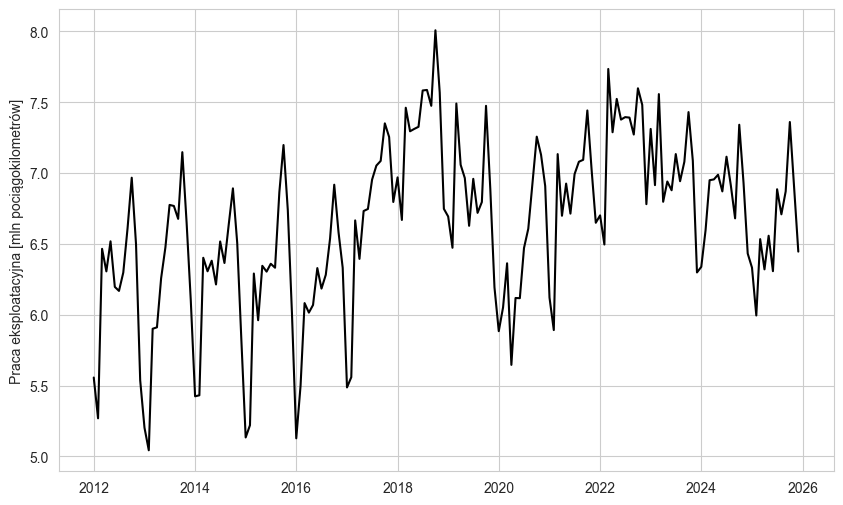

In [31]:
general_plot(
    monthly_data["tow_prac_eksp"],
    file="../figures/tow_prac_eksp.png",
    ylabel="Praca eksploatacyjna [mln pociągokilometrów]",
    title=None,
    save_file=True
)

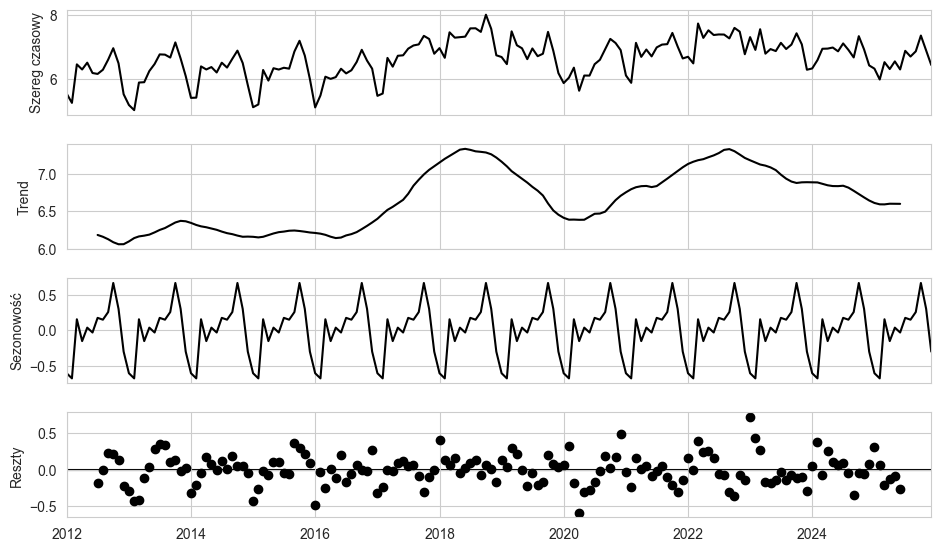

In [32]:
decomp_plot(
    monthly_data["tow_prac_eksp"],
    file="../figures/tow_prac_eksp_decomp.png",
    save_file=True
)